In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_pca, plot_umap, plot_tsne, plot_pca_dark, plot_umap_dark, plot_tsne_dark

# # ---- palette (one place, change here) ----
# PALETTE = "pastel"            # try "muted", "pastel", "Set2", "tab10", "deep"
# sns.set_palette(PALETTE)


/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### CML within-class regime embedding — `cml-small` run (187 blended SPIs)

SPI-SPI feature matrix $f_{ij}=\mathrm{corr}(\mathrm{SPI}_i,\mathrm{SPI}_j)$ over the existing
`data/embeddings/cml-small` run: 10 CML regimes x M in {5,10,20} x T in {500,1000,2000} x 10 instances.
Features generated with `python -m src.process_features --data-path data/embeddings/cml-small --metric pearson`.

Goal: show distinct CML regimes separate in SPI-SPI space, and that the same regime at different (M,T)
co-locates (dimension/length invariance). Pick a regime subset via `SUBSET` below.

##### Candidate regime subsets (ranked)

Ranked by the 5-fold 5-NN regime recall measured on this matrix
(fdstc 1.00, frozen-chaos 0.98, defect-turbulence 0.96, brownian-defect 0.89, sti-i 0.87;
the three traveling-wave variants only confuse *with each other*, so they are merged to one class here).

1. **core-6** *(recommended; = `configs/generate/embeddings/cml-embedding.yaml`)* — maximal dynamical span,
   all subsample-robust: frozen-chaos, brownian-defect, defect-turbulence, sti-i, fdstc, traveling-wave.
2. **turbulence-axis-5** — drops the localized brownian-defect for a clean ordered turbulence progression
   frozen -> STI -> defect-turbulence -> fully-developed, with traveling-wave as an out-group.
3. **cleanest-4** — highest-recall non-redundant quartet, tightest possible embedding for a minimal proof.
4. **all-regimes** — every class in the run (incl. the 3 TW variants, sti-ii, pattern-selection); shows the
   full picture and the expected TW-family overlap.

In [74]:
# Each entry is a list of mts_class names; None would mean "all regimes".
SUBSETS = {
    "core-6": [
        "frozen-chaos", "brownian-defect", "defect-turbulence",
        "sti-i", "fdstc", "traveling-wave",
    ],
    "turbulence-axis-5": [
        "frozen-chaos", "sti-i", "defect-turbulence", "fdstc", "traveling-wave",
    ],
    "cleanest-4": [
        "fdstc", "frozen-chaos", "defect-turbulence", "sti-i",
    ],
    "test": [
        "defect-turbulence", "sti-i", "fdstc", "frozen-chaos",  
        "chaotic-traveling-wave",
    ],
    "1-wave": [
        "brownian-defect", "defect-turbulence", "sti-i", "fdstc", 
        "frozen-chaos", "traveling-wave",
    ],
    "all-regimes": None,   # all 10 classes in the run
}

SUBSET = "test"   # <-- change to any key above

# data = np.load("../../features/data-embeddings-cml-small_pearson.npz", allow_pickle=True)
data = np.load("../../features/data-embeddings-cml-embedding_pearson.npz", allow_pickle=True)

In [75]:
X = data["X"]
y = data["y"]
M = data["M"].astype(int)
T = data["T"].astype(int)
instance = data["instance"]
dataset_paths = data["dataset_paths"]

# --- filters (set to None to disable) ---
M_filter = None              # e.g. 20 to inspect a single channel count
classes = SUBSETS[SUBSET]    # None -> all regimes

mask = np.ones(len(y), dtype=bool)
if M_filter is not None:
    mask &= M == M_filter
if classes is not None:
    mask &= np.isin(y, classes)

X = X[mask]
y = y[mask]
M = M[mask]
T = T[mask]
instance = instance[mask]
dataset_paths = dataset_paths[mask]

meta_df = pd.DataFrame({
    "mts_class": y,
    "M": M,
    "T": T,
    "instance": instance,
    "dataset_paths": dataset_paths,
})
print(f"SUBSET={SUBSET}  X: {X.shape}  classes: {np.unique(y).tolist()}")

SUBSET=test  X: (450, 40174)  classes: ['chaotic-traveling-wave', 'defect-turbulence', 'fdstc', 'frozen-chaos', 'sti-i']


In [76]:
df_playing = meta_df.copy()
df_playing.columns

Index(['mts_class', 'M', 'T', 'instance', 'dataset_paths'], dtype='object')

##### Feature matrix

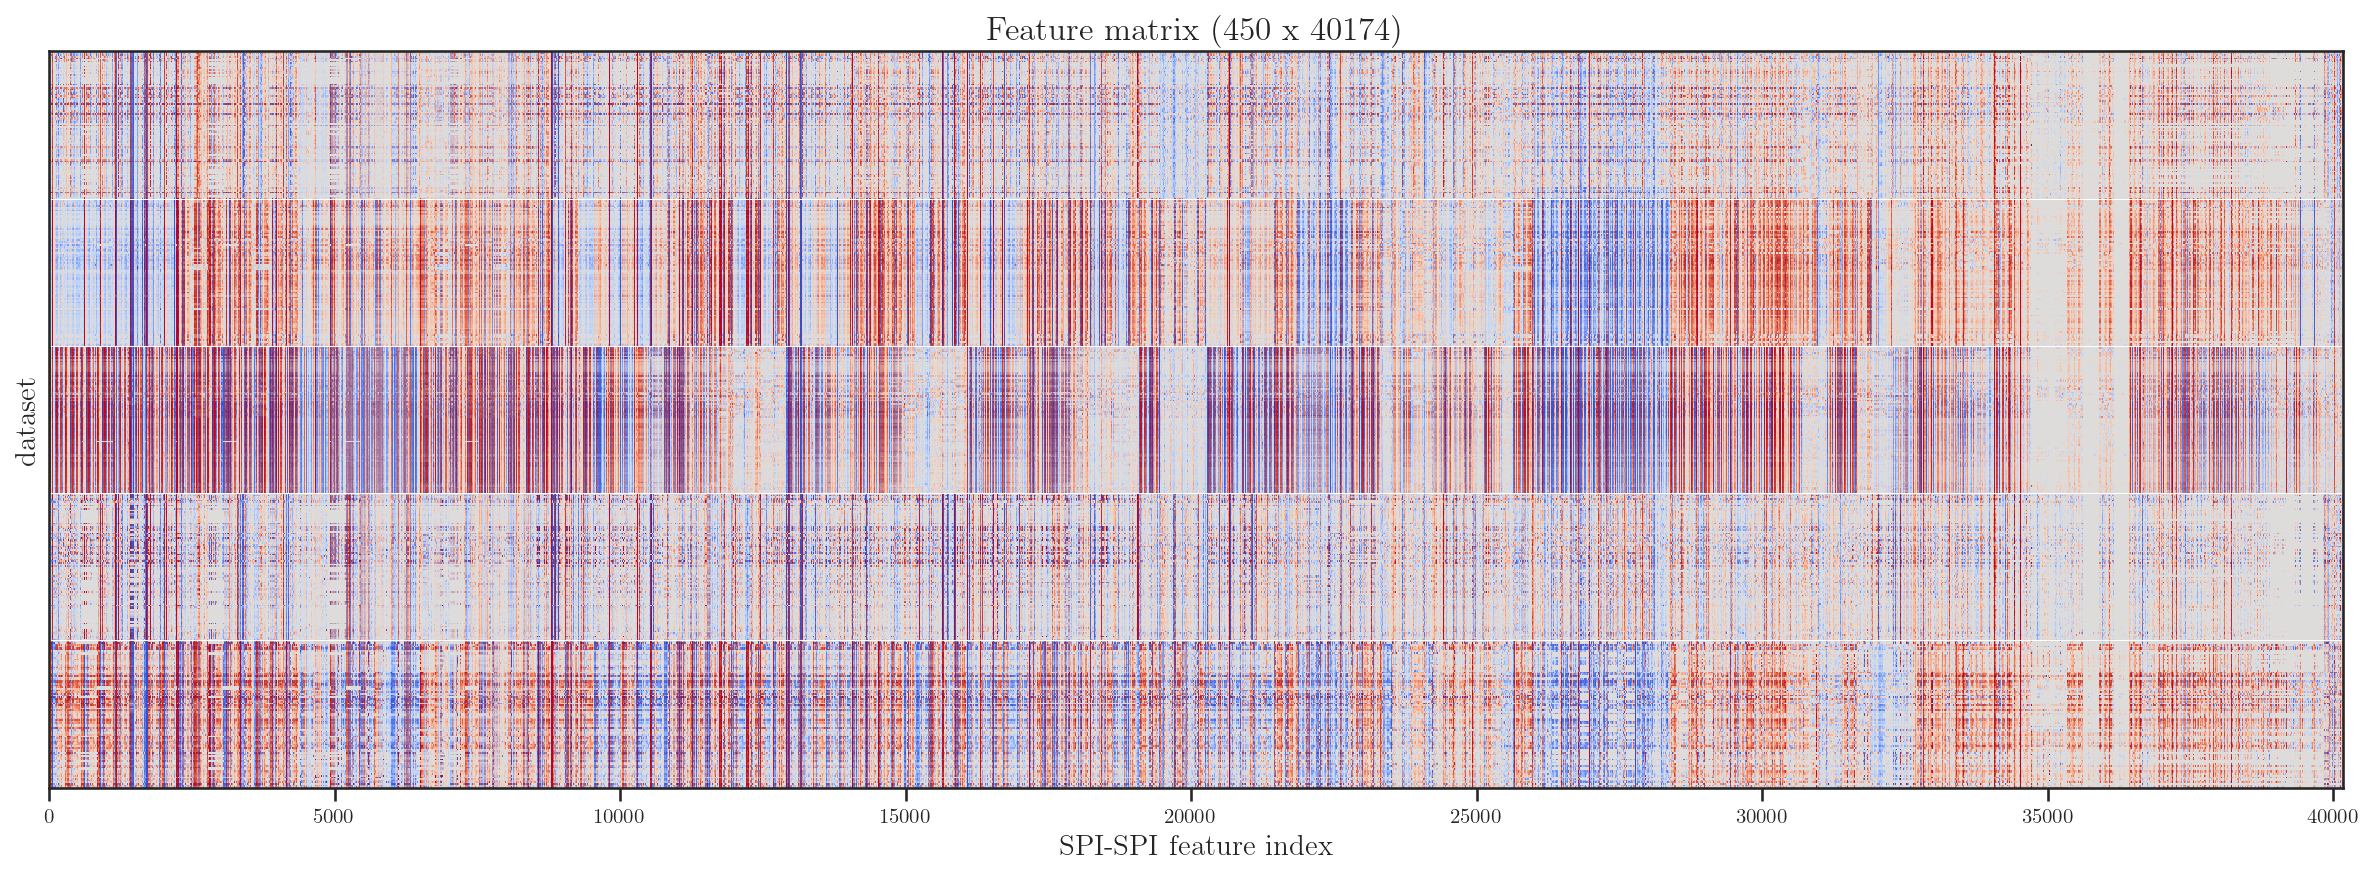

In [77]:
import seaborn as sns

# sort rows by class so blocks are visible
order = np.argsort(y)
X_sorted = X[order]
y_sorted = y[order]

fig, ax = plt.subplots(figsize=(16, 6), dpi=150)
ax.imshow(X_sorted, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1, interpolation="none")
ax.set_xlabel("SPI-SPI feature index")
ax.set_ylabel("dataset")
ax.set_yticks([])
ax.set_title(f"Feature matrix ({X_sorted.shape[0]} x {X_sorted.shape[1]})")

# class boundaries
boundaries = np.where(np.diff(np.searchsorted(np.unique(y_sorted), y_sorted)))[0] + 0.5
for b in boundaries:
    ax.axhline(b, color="white", linewidth=0.5)

plt.tight_layout()
plt.show()

##### PCA - 2D

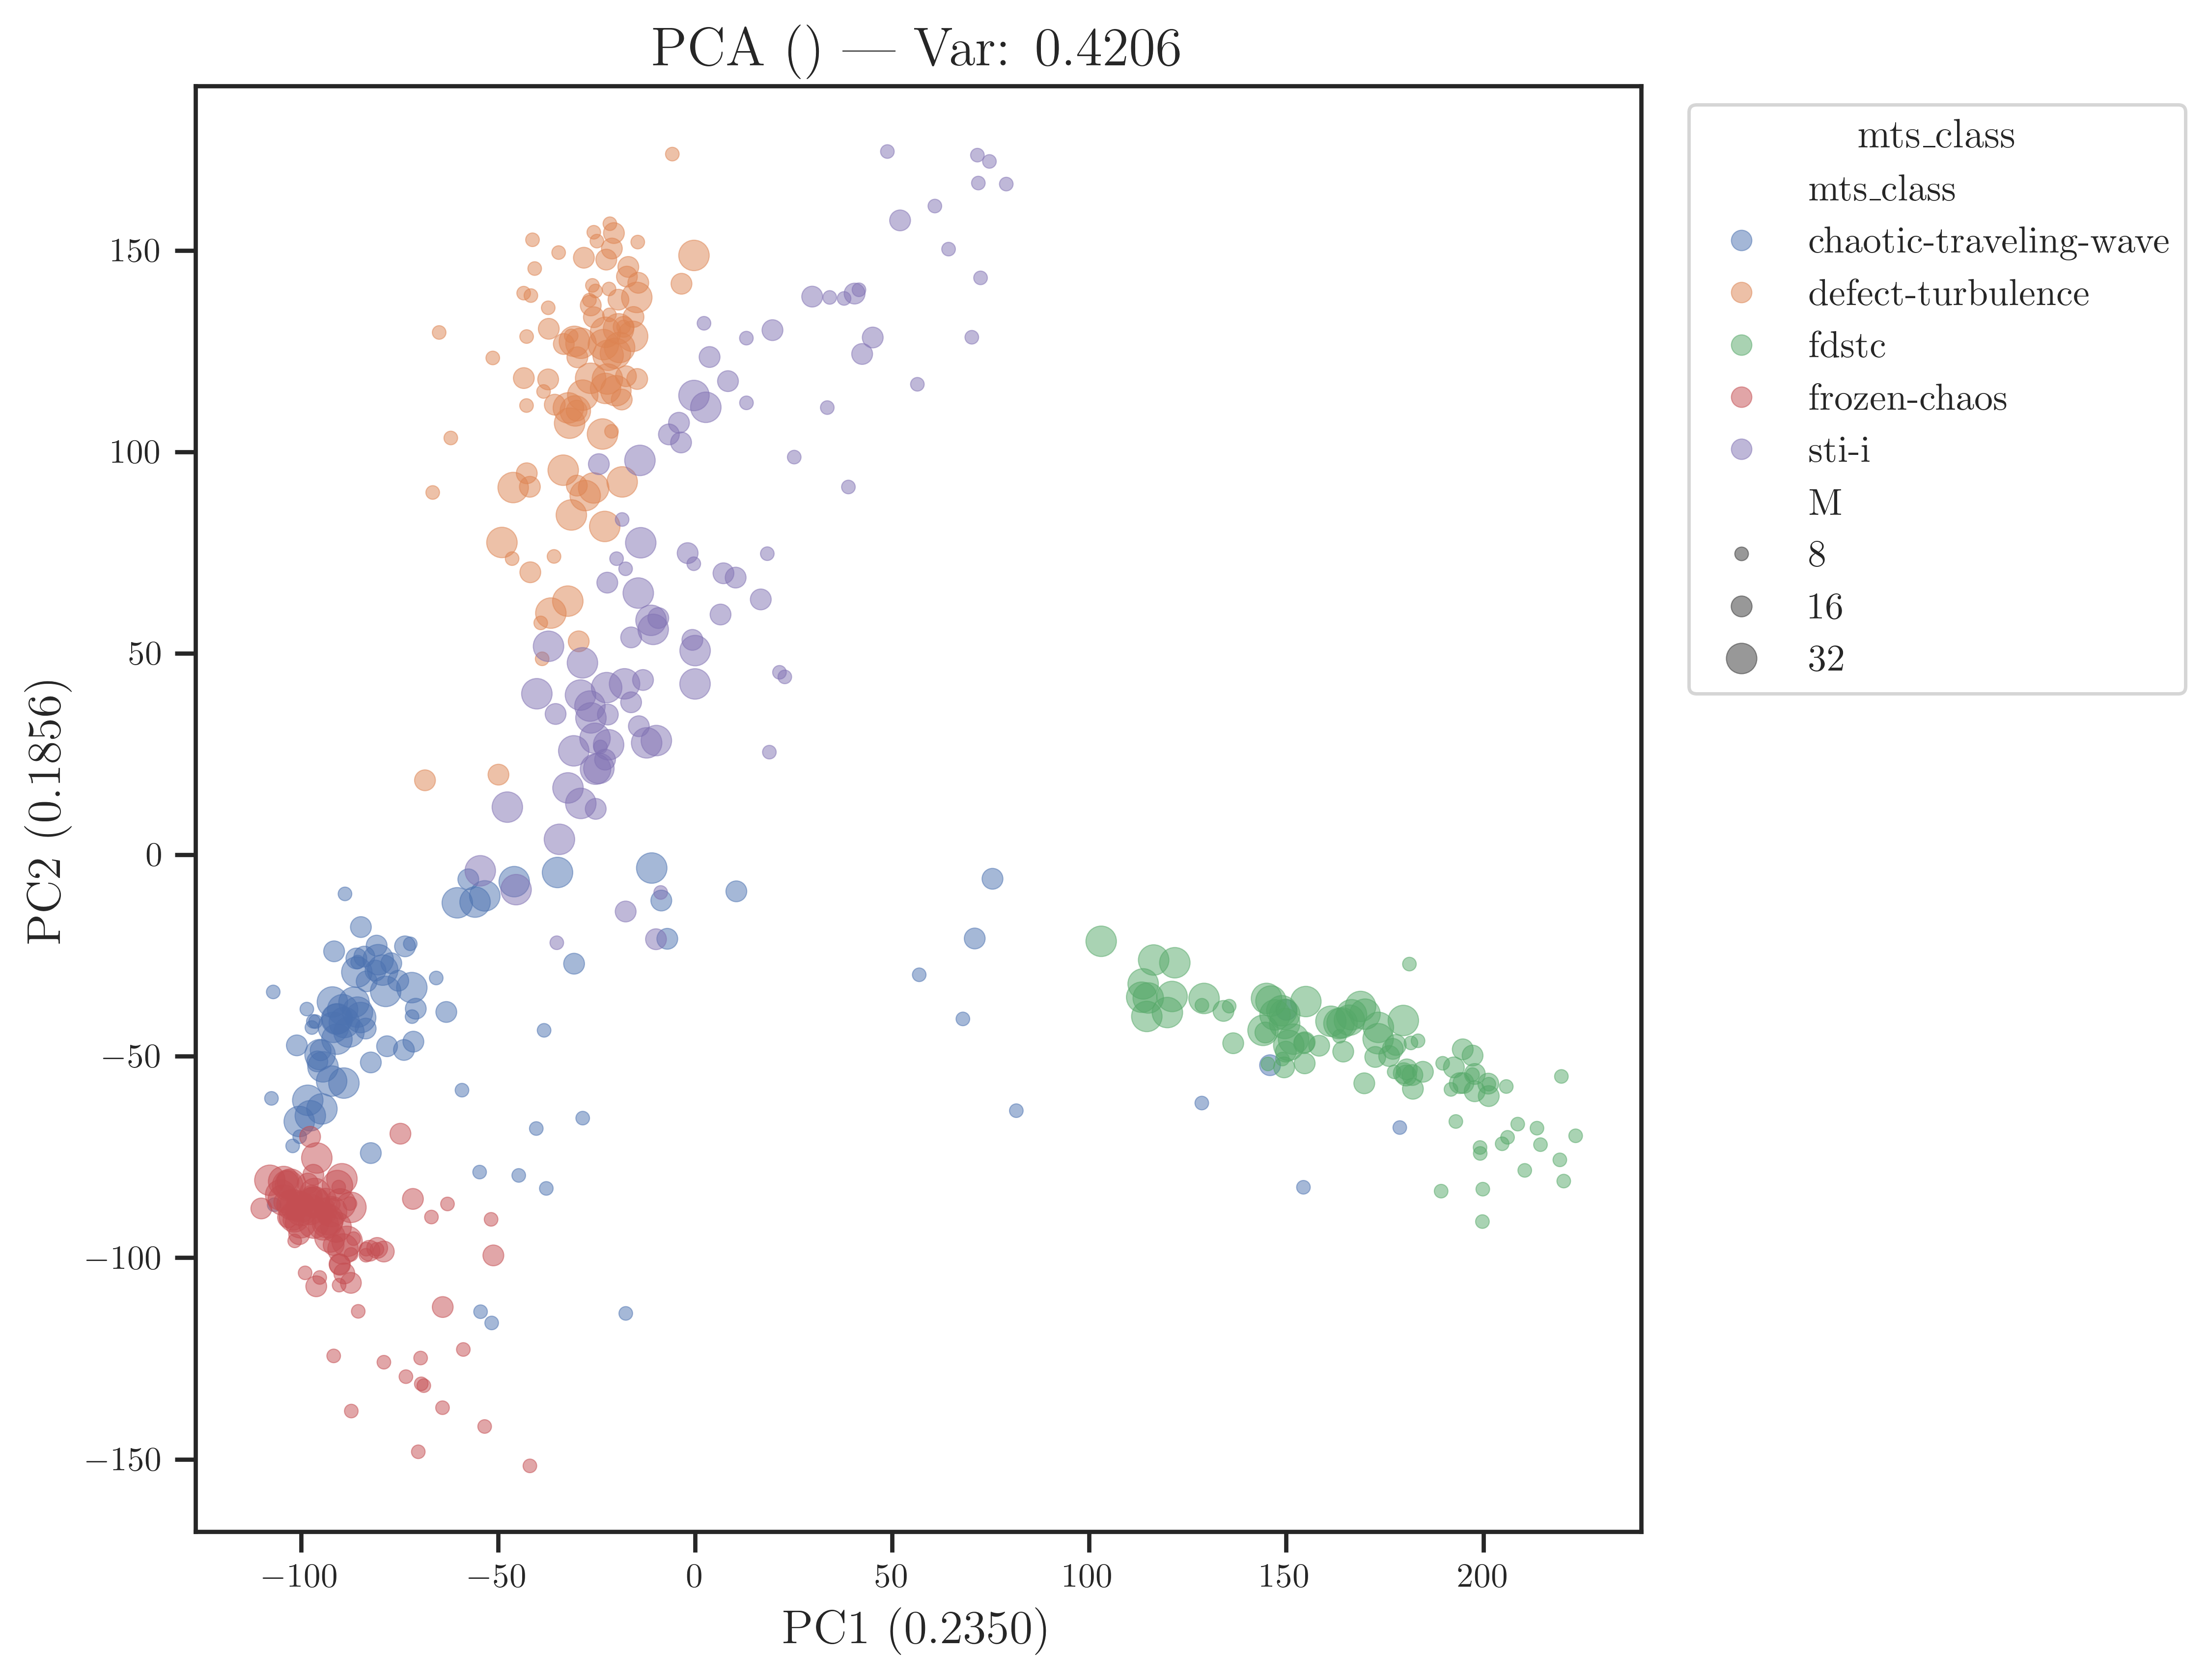

In [78]:
alpha=0.5
s=40
kde=False
ax=True

fig, ax = plt.subplots(figsize=(10, 7), dpi=500)
plot_pca(X, meta_df, alpha=alpha, s=s, ax=ax, kde=kde)
plt.tight_layout(); plt.show()

##### PCA - 3D

In [79]:
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 3D PCA on scaled features (matches plot_pca's StandardScaler step).
X_scaled = StandardScaler().fit_transform(X)
pca3 = PCA(n_components=3, random_state=0)
emb3 = pca3.fit_transform(X_scaled)
var3 = pca3.explained_variance_ratio_

df3 = meta_df.assign(
    pc1=emb3[:, 0], pc2=emb3[:, 1], pc3=emb3[:, 2],
    instance_str=meta_df["instance"].astype(str),
    dataset_paths_str=meta_df["dataset_paths"].astype(str),
)

fig = px.scatter_3d(
    df3, x="pc1", y="pc2", z="pc3",
    color="mts_class",
    size="M", size_max=16,
    hover_data={
        "mts_class": True, "M": True, "T": True,
        "instance_str": True, "dataset_paths_str": False,
        "pc1": ":.2f", "pc2": ":.2f", "pc3": ":.2f",
    },
    title=f"PCA 3D | Var: {var3.sum():.4f}  (PC1 {var3[0]:.3f}, PC2 {var3[1]:.3f}, PC3 {var3[2]:.3f})",
    width=1200, height=900,
)
fig.update_traces(marker=dict(opacity=0.55))
fig.update_layout(legend=dict(title="mts_class"),
                  scene=dict(xaxis_title=f"PC1 ({var3[0]:.3f})",
                             yaxis_title=f"PC2 ({var3[1]:.3f})",
                             zaxis_title=f"PC3 ({var3[2]:.3f})",
                             aspectmode="cube"))
fig.show()


##### UMAP - 2D

PCA pre: 40174 -> 50 PCs | cum. var explained = 0.917


/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


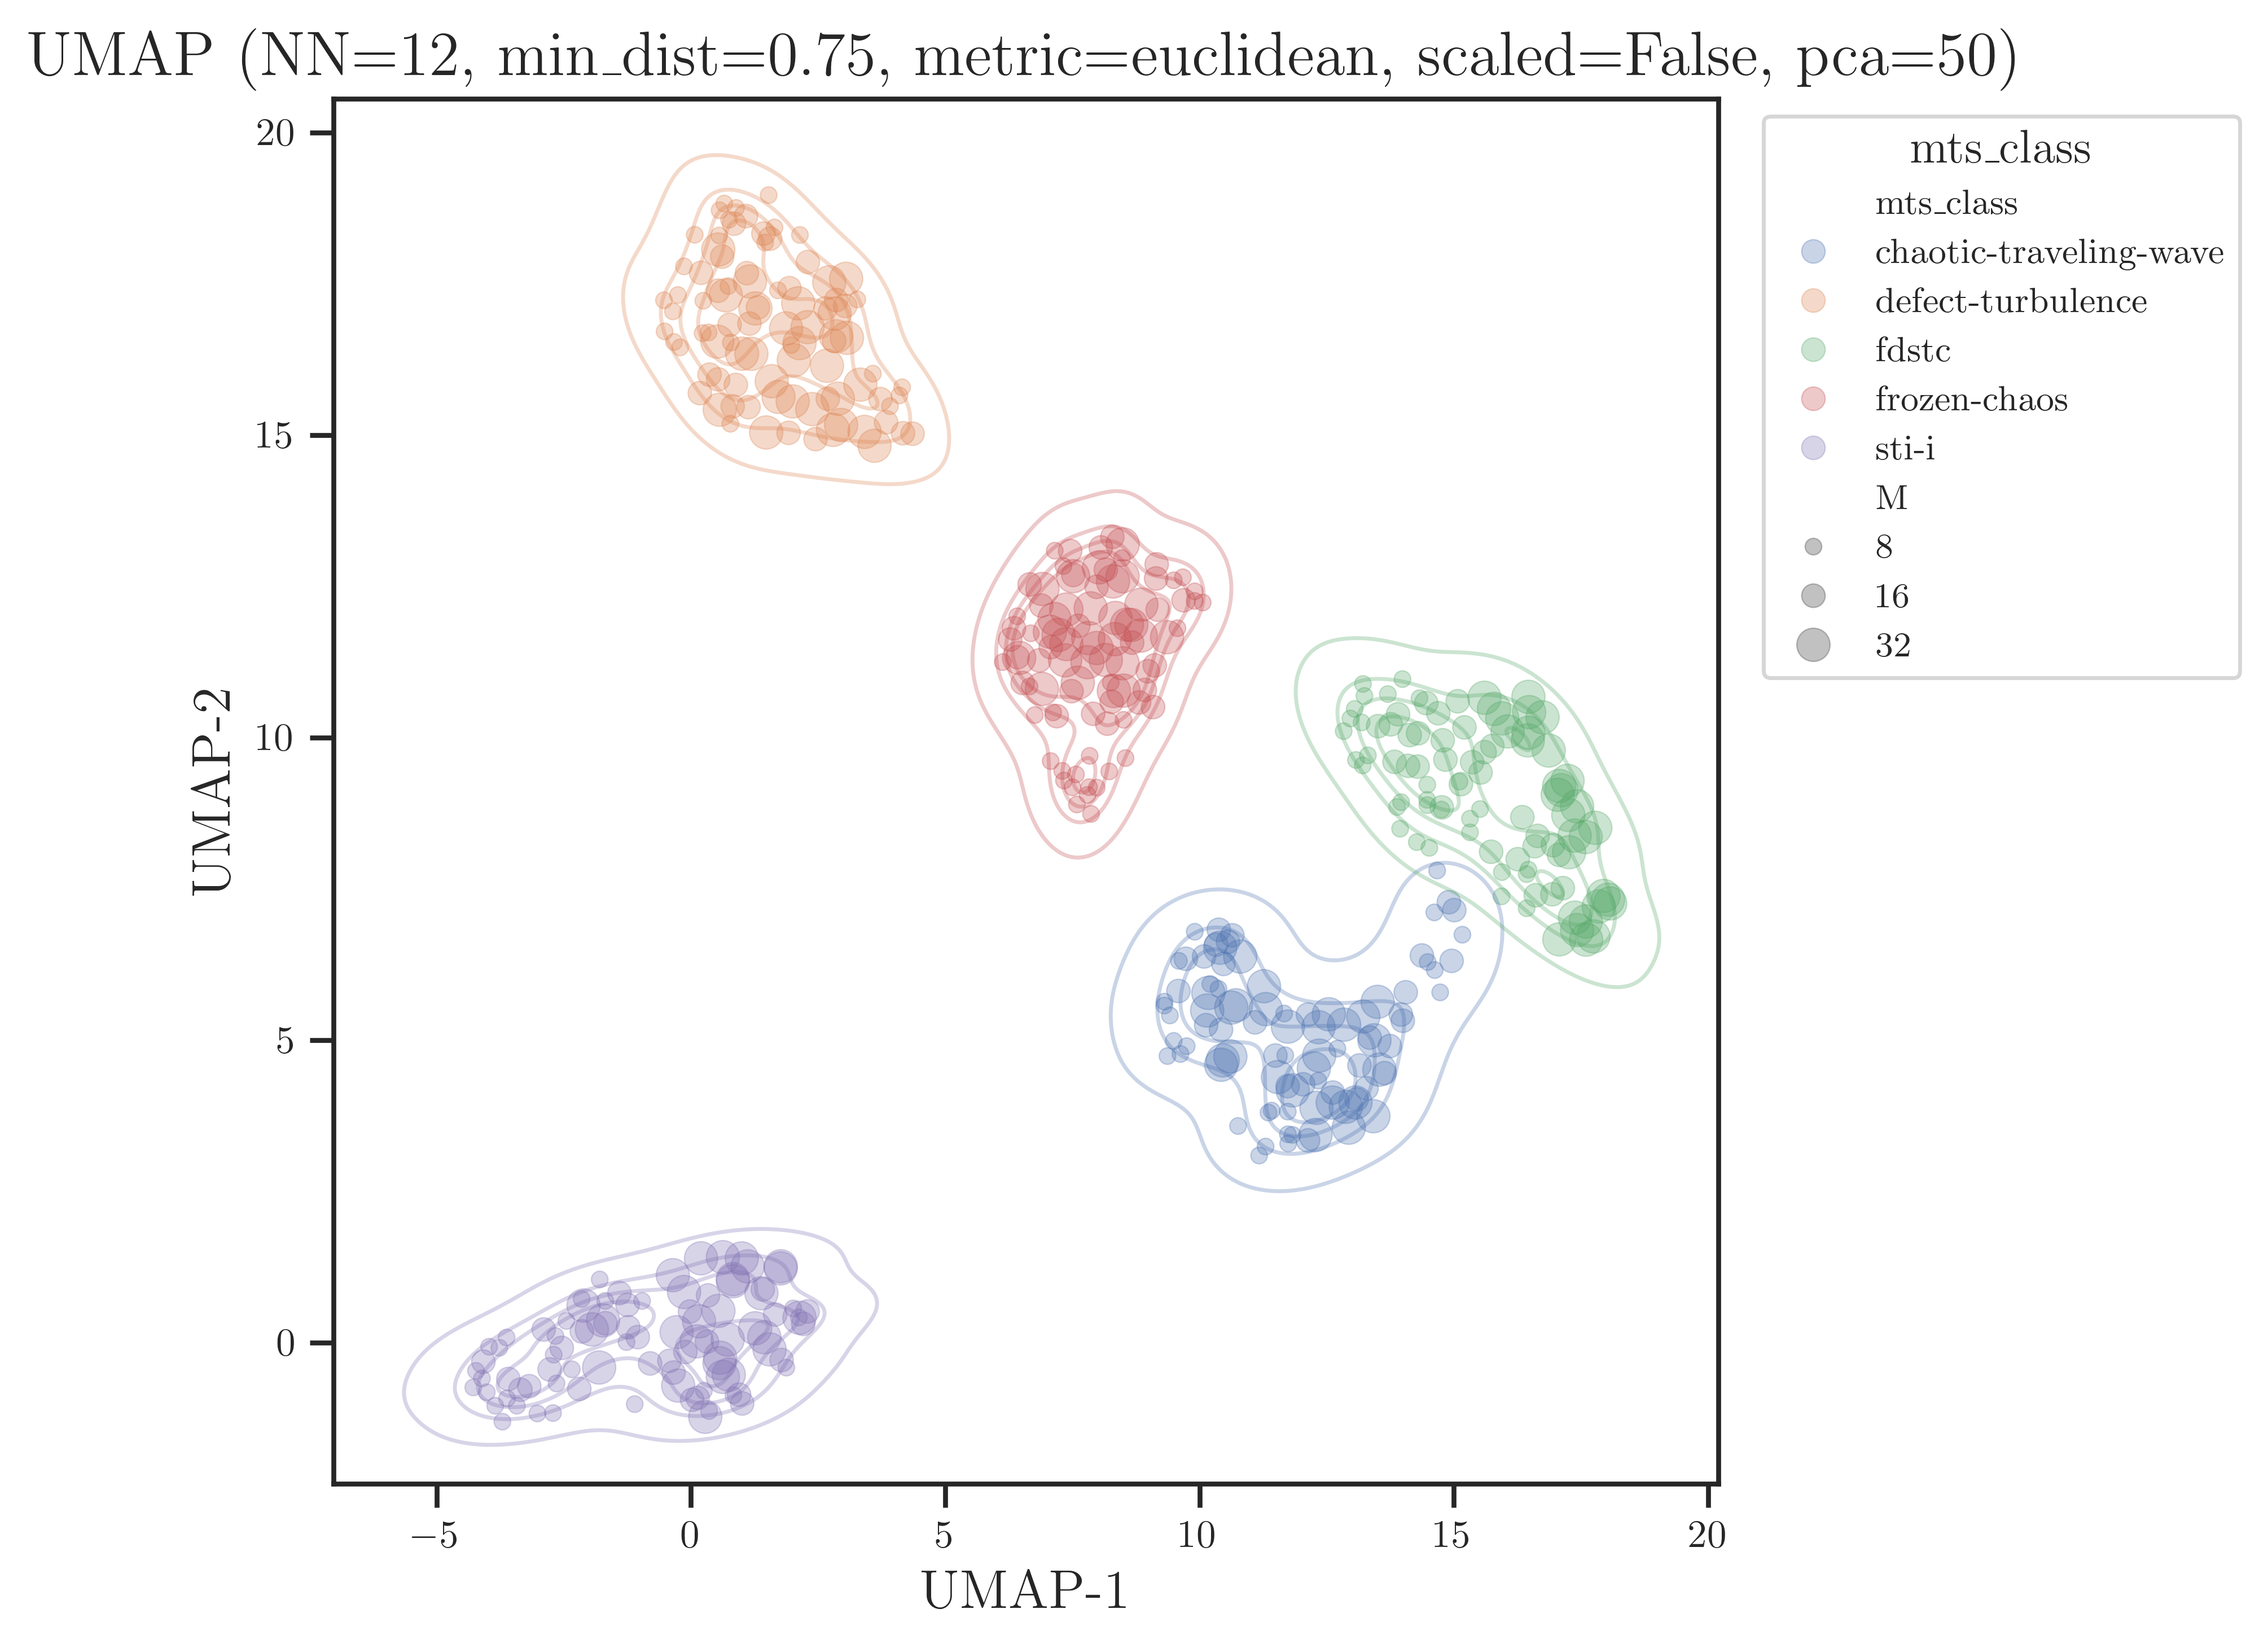

In [94]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP

# --- optional PCA denoising before UMAP -----------------------------------
# p >> n here (~15.5k SPI-SPI features >> few-hundred samples): UMAP's kNN
# graph is built on noisy, redundant coordinates and Euclidean-type distances
# concentrate (Aggarwal 2001). Projecting onto the top PCs first denoises and
# decorrelates WITHIN the SPI-SPI space (a linear rotation of f_ij, no external
# features), then UMAP runs on the compact score space -- standard PCA->UMAP
# practice (McInnes UMAP docs; Becht 2019; Kobak & Berens 2019 for t-SNE).
# NOTE: after PCA, prefer metric="euclidean" (correlation/cosine on ~50 PCs is
# non-standard). Leave scaled=False so PCA is covariance-PCA (keeps informative
# high-variance pairs dominant rather than up-weighting noisy low-variance ones).

# Shared UMAP hyperparameters.
n_neighbors = 12
min_dist = 0.75
metric = "euclidean"   # "euclidean" | "correlation" | "cosine"
scaled = False           # True -> StandardScaler(X); False -> raw X
pca_preprocess = True
n_pca = 50             # PCs retained (capped at min(n_samples, n_features))

X_input = StandardScaler().fit_transform(X) if scaled else X
n_pca_eff = "off"
if pca_preprocess:
    n_pca_eff = min(n_pca, *X_input.shape)
    _pca = PCA(n_components=n_pca_eff, random_state=0).fit(X_input)
    X_input = _pca.transform(X_input)
    print(f"PCA pre: {X.shape[1]} -> {n_pca_eff} PCs | "
          f"cum. var explained = {_pca.explained_variance_ratio_.sum():.3f}")
emb = UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric,
                  random_state=0, verbose=False).fit_transform(X_input)

df_emb = meta_df.assign(umap_x=emb[:, 0], umap_y=emb[:, 1])

fig, ax = plt.subplots(figsize=(8, 6), dpi=500)
sns.kdeplot(data=df_emb, x="umap_x", y="umap_y", hue="mts_class",
            levels=5, alpha=0.3, linewidths=1, ax=ax, legend=False)
sns.scatterplot(data=df_emb, x="umap_x", y="umap_y",
                hue="mts_class", size="M",
                alpha=0.3, edgecolor="face", ax=ax, legend="full")
ax.set_title(f"UMAP (NN={n_neighbors}, min_dist={min_dist}, metric={metric}, scaled={scaled}, pca={n_pca_eff})")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.set_box_aspect(1)
ax.legend(title="mts_class", loc="upper left", bbox_to_anchor=(1.02, 1),
          fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig("../../notebooks/embeddings/graphics/umap_cml_small.svg", dpi=500, bbox_inches="tight")
plt.show()

In [81]:
import plotly.express as px

# Interactive version of the chosen combo (emb_chosen / chosen_label from the cell above).
df_plot = meta_df.assign(
    umap_x=emb[:, 0],
    umap_y=emb[:, 1],
    M_str=meta_df["M"].astype(str),
    instance_str=meta_df["instance"].astype(str),
    dataset_paths_str=meta_df["dataset_paths"].astype(str),
)
fig = px.scatter(
    df_plot, x="umap_x", y="umap_y",
    color="mts_class",
    symbol="M_str",
    hover_data={
        "mts_class": True,
        "M": True,
        "T": True,
        "instance_str": True,
        "dataset_paths_str": False,
        "M_str": False,
        "umap_x": ":.2f",
        "umap_y": ":.2f",
    },
    title=f"UMAP (NN={n_neighbors}, min_dist={min_dist}, metric={metric}, {'scaled' if scaled else 'raw'})",
    width=900, height=700,
)
fig.update_traces(marker=dict(size=9, opacity=0.75))
fig.update_layout(legend=dict(title="mts_class / M"))
fig.show()

## Discriminative f_ij features (per class pair)

Rank single SPI-SPI features by how well they separate a chosen class pair, then plot the
top ones as rainclouds to show the learnable boundary. Scoring = **AUC / Mann-Whitney**
(`sep = max(AUC, 1-AUC)`, 0.5=chance, 1=perfect), with **KS** as a shape-difference flag and a
**permutation null on the best-of-all-features** to control selection bias over ~40k pairs.
`by_cell=True` reports the **min over (M,T) cells** (dimension-invariant separation); pooled
sep=1.0 already implies min-cell=1.0, so the gap (pooled - min_cell) flags M-confounding.
Points are coloured by M. Change `CLASS_A` / `CLASS_B` and re-run.

In [174]:
from matplotlib.colors import to_rgba

def plot_rainclouds(ax, category_labels, data_array, *, order=None, colors=None,
                    size_by=None, size_range=(18, 95), size_label="M", add_size_legend=True,
                    half_width=0.28, box_width=0.045, point_size=5, point_alpha=0.20,
                    jitter=0.02, rng=0):
    """Raincloud per category: cloud = right-half violin joined at its base to a narrow box;
    raw points jittered to the left. Long-form input a la Makie rainclouds(): `category_labels`
    and `data_array` are parallel arrays. Returns `ax` (embed as a subplot).

    Points take their category colour (faint fill via point_alpha, strong same-colour outline).
    `size_by` (per-point scalar parallel to data_array, e.g. M) scales marker size + size legend.
    """
    data_array = np.asarray(data_array, float)
    category_labels = np.asarray(category_labels)
    cats = list(order) if order is not None else list(dict.fromkeys(category_labels.tolist()))
    if colors is None:
        colors = list(sns.color_palette("tab10", len(cats)))
    rs = np.random.default_rng(rng)
    smin = smax = None
    if size_by is not None:
        size_by = np.asarray(size_by, float)
        smin, smax = np.nanmin(size_by), np.nanmax(size_by)
    _to_size = lambda v: size_range[0] + (v - smin) / (smax - smin + 1e-9) * (size_range[1] - size_range[0])

    for i, cat in enumerate(cats):
        m = category_labels == cat
        fin = np.isfinite(data_array[m])
        vals = data_array[m][fin]
        pos, col = i, colors[i % len(colors)]
        if len(vals) >= 2 and np.std(vals) > 1e-9:                       # right-half violin
            for b in ax.violinplot([vals], positions=[pos], widths=half_width * 2,
                                   showextrema=False)["bodies"]:
                v = b.get_paths()[0].vertices
                v[:, 0] = np.clip(v[:, 0], pos, np.inf)
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor("none")
        if len(vals):                                                    # joined narrow box
            ax.boxplot([vals], positions=[pos], widths=box_width, showfliers=False,
                       patch_artist=True, boxprops=dict(facecolor="white", edgecolor=col, lw=1),
                       medianprops=dict(color=col, lw=1.4), whiskerprops=dict(color=col),
                       capprops=dict(color=col))
            jit = pos - box_width - 0.01 - np.abs(rs.normal(0, jitter, len(vals)))  # strip left
            s = _to_size(size_by[m][fin]) if size_by is not None else point_size
            ax.scatter(jit, vals, s=s, facecolors=to_rgba(col, point_alpha),
                       edgecolors=col, linewidths=0.7, zorder=3)
    ax.set_xticks(range(len(cats))); ax.set_xticklabels(cats)
    ax.set_xlim(-0.6, len(cats) - 0.4); ax.grid(True, axis="y", alpha=0.3)
    if size_by is not None and add_size_legend:
        uvals = np.unique(size_by[np.isfinite(size_by)])
        handles = [ax.scatter([], [], s=_to_size(u), facecolors=to_rgba("0.4", point_alpha),
                              edgecolors="0.4", linewidths=0.7, label=f"{int(u)}") for u in uvals]
        ax.legend(handles=handles, title=size_label, labelspacing=1.1, frameon=True,
                  loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    return ax

In [165]:
from scipy.stats import rankdata, ks_2samp

# Full (unfiltered) arrays so the class pair is independent of the embedding SUBSET above.
Xall = data["X"].astype(float); yall = data["y"]
Mall = data["M"].astype(int); Tall = data["T"].astype(int)
PAIRS = data["pairs"]

# (spi_i, spi_j) -> feature column index, order-independent
_PAIR_INDEX = {}
for _i, (_a, _b) in enumerate(PAIRS):
    _PAIR_INDEX[(_a, _b)] = _i; _PAIR_INDEX[(_b, _a)] = _i

def feature_column(spi_i, spi_j):
    """Column index of the SPI-SPI feature corr(spi_i, spi_j) (order-independent)."""
    try:
        return _PAIR_INDEX[(spi_i, spi_j)]
    except KeyError:
        raise KeyError(f"no feature for ({spi_i}, {spi_j}); check names in data['spi_order'].")

def _auc(R, mask_a, na, nb):
    """Directional AUC = P(A>B) per feature from combined-sample ranks R (n x p)."""
    return (R[mask_a].sum(0) - na * (na + 1) / 2) / (na * nb)

def _ks(X, mask_a, na, nb):
    """Vectorised two-sample KS per column: max |ECDF_a - ECDF_b|."""
    order = np.argsort(X, axis=0)
    step = np.where(mask_a[order], 1.0 / na, -1.0 / nb)
    return np.max(np.abs(np.cumsum(step, axis=0)), axis=0)

def pair_separation(a, b, by_cell=True, n_perm=200, rng=0):
    """Rank every f_ij by class-pair separability. Returns (df sorted, null_max).
    df cols: spi_i, spi_j, sep(=max AUC), auc, ks, margin, [min_cell_sep], idx."""
    m = np.isin(yall, [a, b])
    Xab, yab, Mab, Tab = Xall[m], yall[m], Mall[m], Tall[m]
    mask_a = yab == a; na = int(mask_a.sum()); nb = int(len(mask_a) - na)
    R = rankdata(Xab, axis=0)
    auc = _auc(R, mask_a, na, nb); sep = np.maximum(auc, 1 - auc)
    ks = _ks(Xab, mask_a, na, nb)
    med_a = np.median(Xab[mask_a], axis=0); med_b = np.median(Xab[~mask_a], axis=0)
    mad = np.median(np.abs(Xab - np.median(Xab, axis=0)), axis=0) * 1.4826 + 1e-9
    margin = (med_a - med_b) / mad                                  # robust standardised median gap
    cols = {"idx": np.arange(len(sep)), "sep": sep, "auc": auc, "ks": ks, "margin": margin}
    if by_cell:
        mc = np.ones_like(sep)
        for mm in np.unique(Mab):
            for tt in np.unique(Tab):
                cm = (Mab == mm) & (Tab == tt); ca = mask_a[cm]
                nca = int(ca.sum()); ncb = int(cm.sum() - nca)
                if nca and ncb:
                    ac = _auc(rankdata(Xab[cm], axis=0), ca, nca, ncb)
                    mc = np.minimum(mc, np.maximum(ac, 1 - ac))
        cols["min_cell_sep"] = mc
    rs = np.random.default_rng(rng); base = na * (na + 1) / 2; null_max = np.empty(n_perm)
    for i in range(n_perm):                                         # null on best-of-all sep
        ac = (rs.permutation(mask_a) @ R - base) / (na * nb)
        null_max[i] = np.maximum(ac, 1 - ac).max()
    df = pd.DataFrame(cols)
    df["spi_i"] = PAIRS[df["idx"].to_numpy(), 0]; df["spi_j"] = PAIRS[df["idx"].to_numpy(), 1]
    df["absmargin"] = df["margin"].abs()
    sort_key = "min_cell_sep" if by_cell else "sep"
    df = df.sort_values([sort_key, "absmargin"], ascending=False).reset_index(drop=True)
    keep = ["spi_i", "spi_j", "sep", "auc", "ks", "margin"] + (["min_cell_sep"] if by_cell else []) + ["idx"]
    return df[keep], null_max

def youden_threshold(va, vb):
    """Single-feature decision threshold maximising sensitivity + specificity (Youden J)."""
    vals = np.r_[va, vb]; best_t, best_j = float(vals.mean()), -1.0
    for t in np.unique(vals):
        j = (va > t).mean() + (vb <= t).mean() - 1
        if j > best_j:
            best_j, best_t = j, t
    return best_t

def train_test_separation(a, b, test_frac=0.4, rng=0):
    """Held-out check: rank by sep on a train split, report sep on held-out test. The
    train->test drop is the selection-bias optimism. Stratified per class."""
    m = np.isin(yall, [a, b]); yv = yall[m]
    rs = np.random.default_rng(rng); is_test = np.zeros(len(yv), bool)
    for c in (a, b):
        ci = np.where(yv == c)[0]; rs.shuffle(ci)
        is_test[ci[:int(round(test_frac * len(ci)))]] = True
    def _sep(sel):
        Xs = Xall[m][sel]; ms = (yv == a)[sel]; na = int(ms.sum()); nb = int(len(ms) - na)
        au = _auc(rankdata(Xs, axis=0), ms, na, nb); return np.maximum(au, 1 - au)
    df = pd.DataFrame({"idx": np.arange(Xall.shape[1]),
                       "train_sep": _sep(~is_test), "test_sep": _sep(is_test)})
    df["spi_i"] = PAIRS[df["idx"].to_numpy(), 0]; df["spi_j"] = PAIRS[df["idx"].to_numpy(), 1]
    df = df.sort_values("train_sep", ascending=False).reset_index(drop=True)
    return df[["spi_i", "spi_j", "train_sep", "test_sep", "idx"]]

In [166]:
CLASS_A = "brownian-defect"
CLASS_B = "defect-turbulence"
TOPK = 6

ranked, null_max = pair_separation(CLASS_A, CLASS_B, by_cell=True, n_perm=200)
null95 = np.quantile(null_max, 0.95)
print(f"{CLASS_A} vs {CLASS_B}: best-of-40k permutation null (95th pct) sep = {null95:.3f}")
print(f"features clearing null: sep>null95 = {(ranked['sep']>null95).sum()}, "
      f"perfect pooled sep=1.0: {(ranked['sep']>=0.999).sum()}, "
      f"dim-invariant min_cell=1.0: {(ranked['min_cell_sep']>=0.999).sum()}")
ranked.head(TOPK)

brownian-defect vs defect-turbulence: best-of-40k permutation null (95th pct) sep = 0.681
features clearing null: sep>null95 = 20185, perfect pooled sep=1.0: 0, dim-invariant min_cell=1.0: 0


,spi_i,spi_j,sep,auc,ks,margin,min_cell_sep,idx
0,corr_kendall_tau-4,corr_kendall_tau-5-sq,0.975185,0.975185,0.866667,1.332657,0.99,16743
1,corr_kendall_tau-5-sq,pdist_euclidean,0.970864,0.029136,0.855556,-1.328494,0.99,18029
2,corr_kendall_tau-5-sq,sgc_parametric_max_fs-1_fmin-1e-05_fmax-0-5_or...,0.995926,0.004074,0.933333,-1.318093,0.99,18196
3,corr_kendall_tau-5-sq,sgc_parametric_max_fs-1_fmin-0-25_fmax-0-5_ord...,0.995926,0.004074,0.933333,-1.318093,0.99,18198
4,spearmanr,corr_kendall_tau-5-sq,0.967407,0.967407,0.866667,1.306030,0.99,8838
5,corr_kendall_tau-5-sq,pdist_canberra,0.973210,0.026790,0.877778,-1.304584,0.99,18033


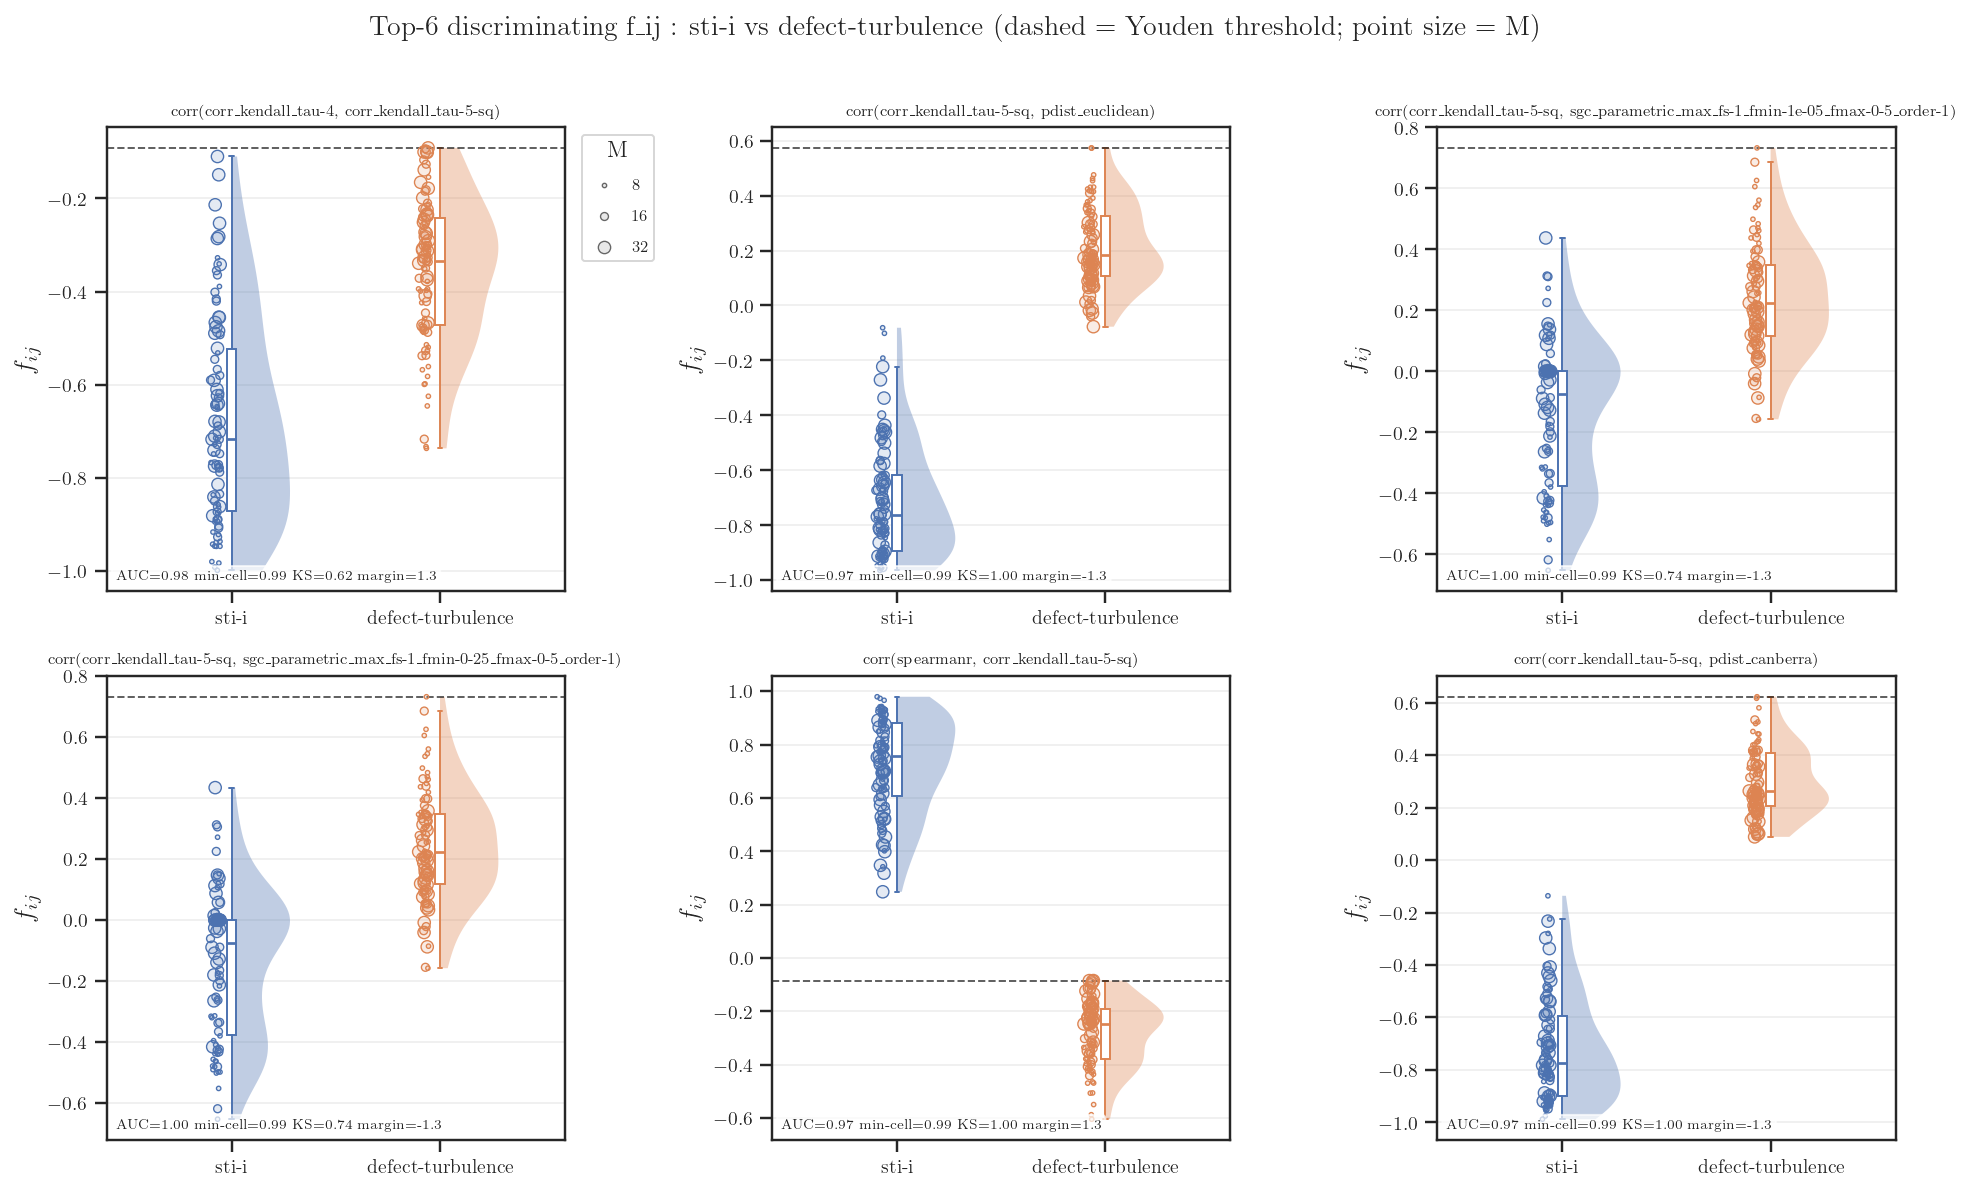

In [175]:
ncol = 3; nrow = int(np.ceil(TOPK/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6*ncol, 4.2*nrow), dpi=140)
axes = np.atleast_1d(axes).ravel()
m = np.isin(yall, [CLASS_A, CLASS_B])
Xab, yab, Mab = Xall[m], yall[m], Mall[m]
# pick TOPK *diverse* features: skip a pair only if BOTH its SPIs are already shown
# (thousands may tie at sep=1.0; this avoids six near-duplicate covariance panels).
used = set(); picks = []
for _, r in ranked.iterrows():
    s0, s1 = PAIRS[int(r["idx"]), 0], PAIRS[int(r["idx"]), 1]
    if s0 in used and s1 in used:
        continue
    picks.append(r); used.update([s0, s1])
    if len(picks) >= TOPK:
        break
for k, row in enumerate(picks):
    i = int(row["idx"]); ax = axes[k]
    va, vb = Xab[yab==CLASS_A, i], Xab[yab==CLASS_B, i]
    plot_rainclouds(ax, yab, Xab[:, i], order=[CLASS_A, CLASS_B],
                    colors=["#4C72B0", "#DD8452"], size_by=Mab,size_range=(5,40), 
                    point_size=10, point_alpha=0.15, add_size_legend=(k == 0))
    thr = youden_threshold(va, vb); ks = ks_2samp(va, vb).statistic
    ax.axhline(thr, color="k", ls="--", lw=1, alpha=0.7)
    ax.set_title(f"corr({row['spi_i']}, {row['spi_j']})", fontsize=8)
    ax.set_ylabel(r"$f_{ij}$")
    ax.text(0.02, 0.02, f"AUC={row['sep']:.2f}  min-cell={row['min_cell_sep']:.2f}  "
                        f"KS={ks:.2f}  margin={row['margin']:.1f}",
            transform=ax.transAxes, fontsize=7, va="bottom",
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))
for k in range(len(picks), len(axes)): axes[k].axis("off")
fig.suptitle(f"Top-{TOPK} discriminating f_ij : {CLASS_A} vs {CLASS_B}  "
             f"(dashed = Youden threshold; point size = M)", y=1.01)
fig.tight_layout(); plt.show()

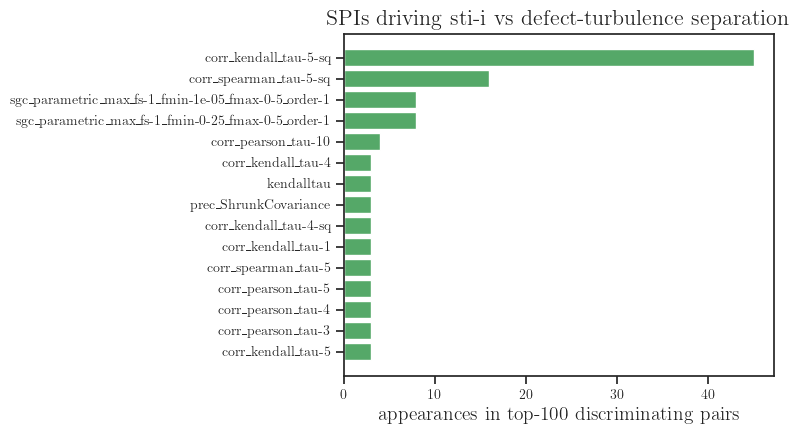

In [176]:
# Which individual SPIs recur across the top discriminating pairs? Names the dependence
# axes (e.g. lagged-correlation, DTW, coherence band) that drive the separation.
from collections import Counter
TOP_FOR_UNION = 100
cnt = Counter()
for i in ranked["idx"].head(TOP_FOR_UNION):
    cnt[PAIRS[i, 0]] += 1; cnt[PAIRS[i, 1]] += 1
top_spi = cnt.most_common(15)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh([s for s, _ in top_spi][::-1], [c for _, c in top_spi][::-1], color="#55A868")
ax.set_xlabel(f"appearances in top-{TOP_FOR_UNION} discriminating pairs")
ax.set_title(f"SPIs driving {CLASS_A} vs {CLASS_B} separation"); fig.tight_layout(); plt.show()

### Single raincloud: pick two classes and two SPIs
Edit the four variables and re-run. Points are category-coloured (faint fill, strong outline); **size encodes M**.

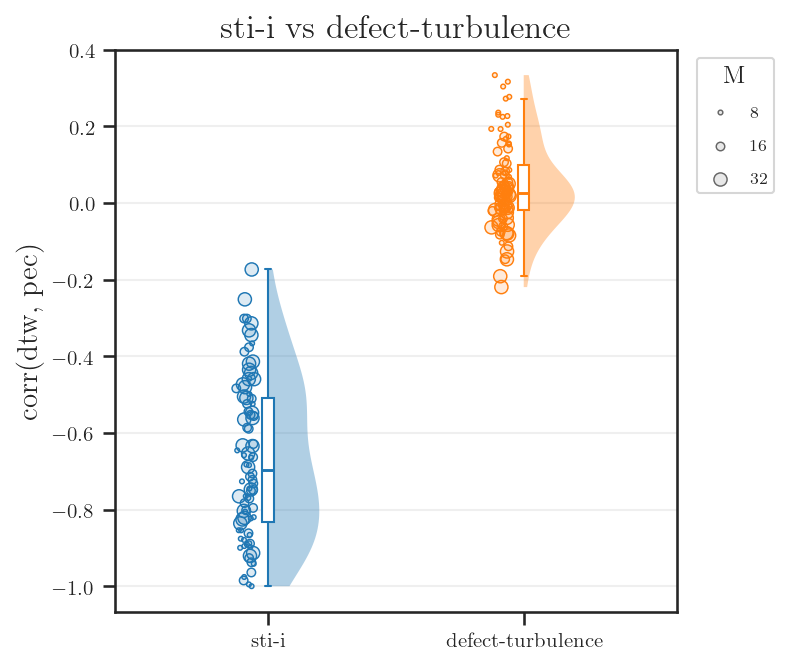

In [196]:
# --- Raincloud for two classes x two SPIs (edit these four lines) ---
CLASS_A = "sti-i"
CLASS_B = "defect-turbulence"
spi_i = "dtw"
spi_j = "pec"

i = feature_column(spi_i, spi_j)
m = np.isin(yall, [CLASS_A, CLASS_B])
fig, ax = plt.subplots(figsize=(6.5, 4.6), dpi=150)
plot_rainclouds(ax, yall[m], Xall[m, i], order=[CLASS_A, CLASS_B], 
                half_width=0.20, box_width=0.045, jitter=0.03, rng=0,
                size_by=Mall[m], size_range=(5, 40), point_size=10, point_alpha=0.15
                )
ax.set_ylabel(f"corr({spi_i}, {spi_j})"); ax.set_title(f"{CLASS_A} vs {CLASS_B}")
ax.set_box_aspect(1); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

### Histogram alternative (density)
Simple overlaid density histograms for the same `corr(spi_i, spi_j)` feature.

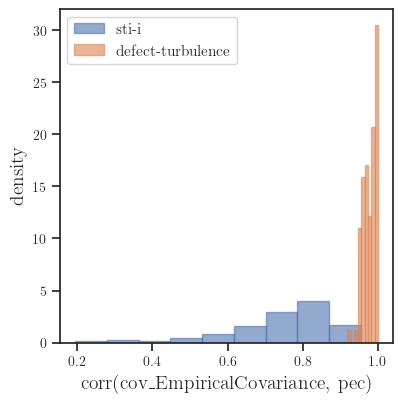

In [193]:
def plot_feature_hist(class_a, class_b, spi_i, spi_j, *, bins=9, ax=None,
                      colors=("#4C72B0", "#DD8452")
                      ):
    """Overlaid density histograms of corr(spi_i, spi_j) for two classes (simple alternative
    to the raincloud). Density on the vertical axis. Returns ax."""
    i = feature_column(spi_i, spi_j)
    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 4.2))
    for c, col in zip((class_a, class_b), colors):
        v = Xall[yall == c, i]; v = v[np.isfinite(v)]
        ax.hist(v, bins=bins, density=True, alpha=0.6, color=col, edgecolor=col, label=c)
    ax.set_xlabel(f"corr({spi_i}, {spi_j})"); ax.set_ylabel("density"); ax.legend()
    ax.set_box_aspect(1)
    return ax

plot_feature_hist(CLASS_A, CLASS_B, spi_i, spi_j); plt.tight_layout(); plt.show()

### KS-stat ranking
Same features, ranked by the two-sample KS statistic (sensitive to shape/scale differences AUC can miss).

In [172]:
# KS-stat ranking (shape-difference flag): same table, sorted by KS instead of AUC/sep.
ranked.sort_values("ks", ascending=False).head(TOPK)

,spi_i,spi_j,sep,auc,ks,margin,min_cell_sep,idx
40173,lmfit_Lasso,lmfit_ElasticNet,0.5,0.5,0.966667,0.0,0.5,39944
38486,mi_gaussian,dspli_multitaper_max_fs-1_fmin-0_fmax-0-5,0.5,0.5,0.966667,0.0,0.5,29347
38643,te_kraskov_NN-4_DCE_k-2_kt-1_l-1_lt-1,dspli_multitaper_max_fs-1_fmin-0_fmax-0-5,0.5,0.5,0.966667,0.0,0.5,31167
38633,te_symbolic_k-10_kt-1_l-1_lt-1,dswpli_multitaper_max_fs-1_fmin-0_fmax-0-5,0.5,0.5,0.966667,0.0,0.5,31039
38630,te_symbolic_k-10_kt-1_l-1_lt-1,dspli_multitaper_max_fs-1_fmin-0_fmax-0-5,0.5,0.5,0.966667,0.0,0.5,31033
38621,gc_gaussian_k-1_kt-1_l-1_lt-1,dswpli_multitaper_max_fs-1_fmin-0_fmax-0-5,0.5,0.5,0.966667,0.0,0.5,30904


### Held-out train/test separation
Guards against selection bias over ~40k features: rank on train, report held-out test sep.

In [185]:
# Held-out train/test: rank by sep on 60% train, report sep on 40% held-out test.
# A large train->test drop = selection-bias optimism; stable test_sep = a real boundary.
ht = train_test_separation(CLASS_A, CLASS_B, test_frac=0.4)
print(f"{CLASS_A} vs {CLASS_B}: top features by TRAIN sep, with held-out TEST sep")
ht.head(20)

sti-i vs defect-turbulence: top features by TRAIN sep, with held-out TEST sep


,spi_i,spi_j,train_sep,test_sep,idx
0,corr_spearman_tau-4-sq,pec,1.0,1.000000,14967
1,cov-sq_EmpiricalCovariance,corr_spearman_tau-1,1.0,1.000000,2268
2,cov-sq_EmpiricalCovariance,corr_spearman_tau-3,1.0,1.000000,2270
3,cov-sq_EmpiricalCovariance,corr_spearman_tau-4,1.0,0.999228,2271
4,cov-sq_EmpiricalCovariance,corr_spearman_tau-5,1.0,1.000000,2272
5,corr_kendall_tau-10-sq,gc_gaussian_k-1_kt-1_l-1_lt-1,1.0,1.000000,18509
6,corr_kendall_tau-10-sq,phi_Geo_t-1_norm-0,1.0,1.000000,18515
7,corr_kendall_tau-10-sq,phi_Geo_t-1_norm-1,1.0,1.000000,18516
8,corr_pearson_tau-10-sq,phi_Geo_t-1_norm-0,1.0,1.000000,12313
9,cov-sq_EmpiricalCovariance,corr_spearman_tau-10,1.0,1.000000,2278
